<a href="https://colab.research.google.com/github/Sonunagesh/Forest-Fire-Risk-Assessment/blob/wildfire-detection/wildfire_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

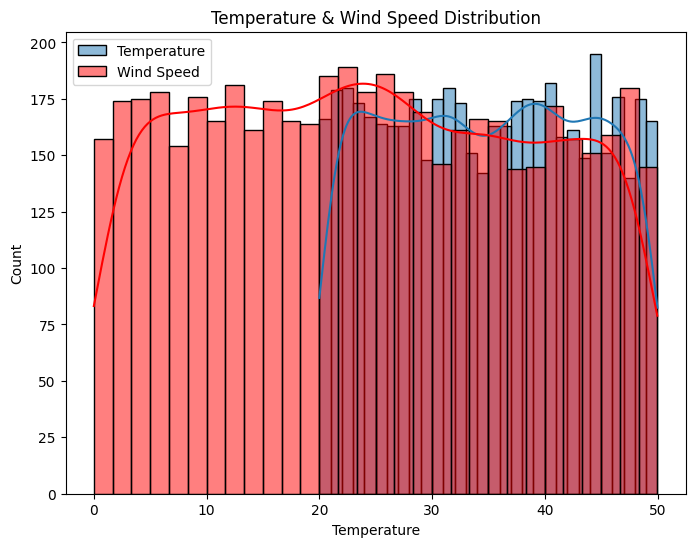

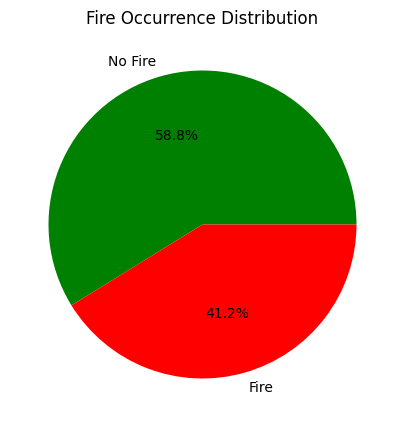

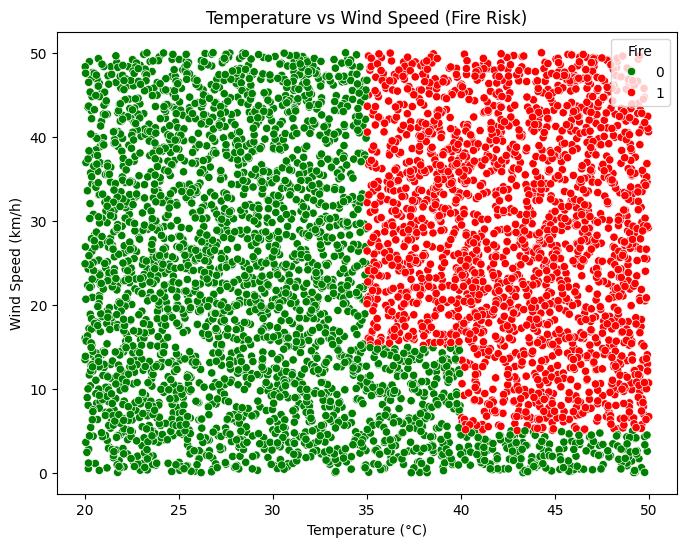

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5800 - loss: 0.6816 - val_accuracy: 0.5912 - val_loss: 0.6760
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5861 - loss: 0.6785 - val_accuracy: 0.5912 - val_loss: 0.6762
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5836 - loss: 0.6794 - val_accuracy: 0.5912 - val_loss: 0.6766
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5841 - loss: 0.6791 - val_accuracy: 0.5912 - val_loss: 0.6771
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5829 - loss: 0.6794 - val_accuracy: 0.5912 - val_loss: 0.6774
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5807 - loss: 0.6807 - val_accuracy: 0.5912 - val_loss: 0.6762
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5979 - loss: 0.6743 - val_accuracy: 0.5912 - val_loss: 0.6770
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5830 - loss: 0.6796 - val_accu

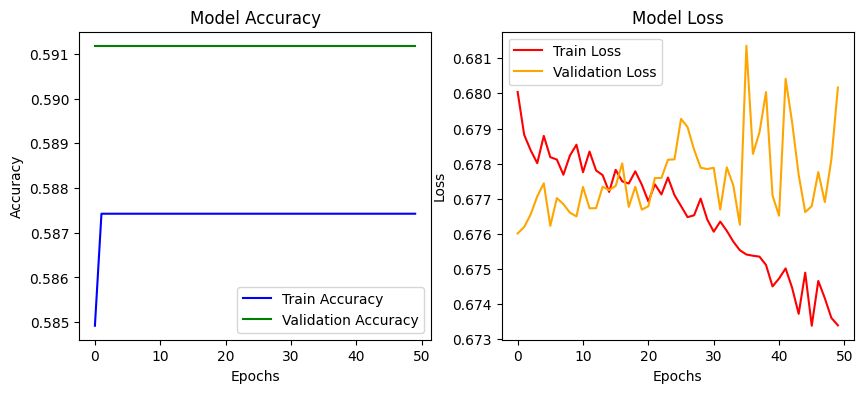

Enter Temperature (in Celsius): 28
Enter Wind Speed (km/h): 10


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
🔥 Fire Probability: ✅ No Fire Risk
Do you want to enter another input? (yes/no): yes
Enter Temperature (in Celsius): 35
Enter Wind Speed (km/h): 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


🔥 Fire Probability: ✅ No Fire Risk
Do you want to enter another input? (yes/no): yes
Enter Temperature (in Celsius): 45
Enter Wind Speed (km/h): 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


...

🔥 Fire Probability: ⚠ Moderate Fire Risk
Do you want to enter another input? (yes/no): yes
Enter Temperature (in Celsius): 100
Enter Wind Speed (km/h): 25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


🔥 Fire Probability: ⚠ Moderate Fire Risk
Do you want to enter another input? (yes/no): yes
Enter Temperature (in Celsius): 1000
Enter Wind Speed (km/h): 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


🔥 Fire Probability: 🔥 High Fire Risk
Do you want to enter another input? (yes/no): no


In [ ]:
# Install required libraries (if not installed)
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset with more fire cases
timesteps = 5000  # Increased dataset size for better training

temp = np.random.uniform(20, 50, timesteps)  # Temperature (20°C - 50°C)
wind_speed = np.random.uniform(0, 50, timesteps)  # Wind Speed (0 - 50 km/h)

# Fire condition logic: Fire occurs if high temperature and wind speed are high
fire_occurred = ((temp > 35) & (wind_speed > 15)) | ((temp > 40) & (wind_speed > 5))
fire_occurred = fire_occurred.astype(int)  # Convert to binary labels (0 = No Fire, 1 = Fire)

# Create DataFrame
data = pd.DataFrame({'Temperature': temp, 'WindSpeed': wind_speed, 'Fire': fire_occurred})

# 🔹 *Data Visualization*
plt.figure(figsize=(8, 6))
sns.histplot(data['Temperature'], bins=30, kde=True, label="Temperature")
sns.histplot(data['WindSpeed'], bins=30, kde=True, label="Wind Speed", color='r')
plt.legend()
plt.title("Temperature & Wind Speed Distribution")
plt.show()

# 🔹 *Fire Occurrence Pie Chart*
plt.figure(figsize=(5, 5))
labels = ['No Fire', 'Fire']
plt.pie(data['Fire'].value_counts(), labels=labels, autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Fire Occurrence Distribution")
plt.show()

# 🔹 *Scatter Plot: Temperature vs Wind Speed*
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['Temperature'], y=data['WindSpeed'], hue=data['Fire'], palette={0: 'green', 1: 'red'})
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind Speed (km/h)")
plt.title("Temperature vs Wind Speed (Fire Risk)")
plt.show()

# Normalize Data
scaler = MinMaxScaler()
data[['Temperature', 'WindSpeed']] = scaler.fit_transform(data[['Temperature', 'WindSpeed']])

# Function to create sequences for LSTM
sequence_length = 10
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data.iloc[i:i+sequence_length, :-1].values)
        y.append(data.iloc[i+sequence_length, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(data, sequence_length)

# Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build LSTM Model with more neurons
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 2)),
    Dropout(0.3),
    LSTM(50, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model for more epochs
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# 🔹 *Plot Training Accuracy & Loss*
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# 🔥 *Fire Prediction Function with Better Risk Assessment*
def predict_fire(temperature, wind_speed):
    user_input = scaler.transform([[temperature, wind_speed]])
    input_sequence = np.vstack([X_test[-1][1:], user_input])
    input_sequence = input_sequence.reshape(1, sequence_length, 2)

    prediction = model.predict(input_sequence)[0][0]

    if prediction > 0.7:
        return '🔥 High Fire Risk'
    elif prediction > 0.4:
        return '⚠ Moderate Fire Risk'
    else:
        return '✅ No Fire Risk'

# *Multiple Input Handling*
while True:
    try:
        temp_input = float(input("Enter Temperature (in Celsius): "))
        wind_input = float(input("Enter Wind Speed (km/h): "))

        # Predict and display result
        result = predict_fire(temp_input, wind_input)
        print(f"🔥 Fire Probability: {result}")

        # Ask user if they want to continue
        cont = input("Do you want to enter another input? (yes/no): ").strip().lower()
        if cont != 'yes':
            break

    except ValueError:
        print("Invalid input. Please enter numeric values.")
